In this notebook, we demonstrate usage of SpotSweeper_py on a public Visium dataset. Specifically, the sample is taken from human breast cancer, FFPE tissue block using IF. The data summary could be obtained here: https://www.10xgenomics.com/datasets/gene-and-protein-expression-library-of-human-breast-cancer-cytassist-ffpe-2-standard

To get started with the analysis, we process the dataset and convert into AnnData object.

In [8]:
import squidpy as sq
adata = sq.read.visium(
    path="/users/xchen5/paper_spotsweeperpy/Visium",
    counts_file="CytAssist_FFPE_Protein_Expression_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
)

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Similar analyses are conducted below (see Visium HD notebook).

**Global QC: Violin Plots**

In [31]:
import scanpy as sc
import numpy as np
from scipy.stats import median_abs_deviation

adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-') # mark mitochondrial genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True) 
adata.obs["log_total_counts"] = np.log1p(adata.obs["total_counts"])

def is_outlier(vec, nmads=3, log=False, direction='both'):
    arr = np.log1p(vec) if log else np.asarray(vec)
    med = np.nanmedian(arr)
    mad = median_abs_deviation(arr, nan_policy='omit')
    lower = med - nmads * mad
    upper = med + nmads * mad
    if direction == 'lower':
        return arr < lower
    elif direction == 'higher':
        return arr > upper
    else:
        return (arr < lower) | (arr > upper)
    
adata.obs['low_counts_outlier'] = is_outlier(adata.obs['total_counts'], direction='lower')
adata.obs['low_log_counts_outlier'] = is_outlier(adata.obs['log_total_counts'], direction='lower')
adata.obs['high_mt_outlier']   = is_outlier(adata.obs['pct_counts_mt'], direction='higher')
adata.obs['low_genes_outlier'] = is_outlier(adata.obs['n_genes_by_counts'], direction='lower')

# combine into one global flag
adata.obs['all_metrics_outlier'] = (
    adata.obs['low_counts_outlier'] | adata.obs['low_log_counts_outlier'] | adata.obs['high_mt_outlier'] | adata.obs['low_genes_outlier']
)

print(adata.obs['low_counts_outlier'].value_counts())
print(adata.obs['low_log_counts_outlier'].value_counts())
print(adata.obs['high_mt_outlier'].value_counts())
print(adata.obs['low_genes_outlier'].value_counts())
print(adata.obs['all_metrics_outlier'].value_counts())

# Summarize and print percentages
for col in [
    "low_counts_outlier",
    "low_log_counts_outlier",
    "high_mt_outlier",
    "low_genes_outlier",
    "all_metrics_outlier"
]:
    flagged = adata.obs[col].sum()             # number of True values
    total = adata.n_obs                        # total spots
    perc = flagged / total * 100
    print(f"{col}: {flagged}/{total} spots ({perc:.2f}%) flagged")

low_counts_outlier
False    4169
Name: count, dtype: int64
low_log_counts_outlier
False    3940
True      229
Name: count, dtype: int64
high_mt_outlier
False    3561
True      608
Name: count, dtype: int64
low_genes_outlier
False    4019
True      150
Name: count, dtype: int64
all_metrics_outlier
False    3334
True      835
Name: count, dtype: int64
low_counts_outlier: 0/4169 spots (0.00%) flagged
low_log_counts_outlier: 229/4169 spots (5.49%) flagged
high_mt_outlier: 608/4169 spots (14.58%) flagged
low_genes_outlier: 150/4169 spots (3.60%) flagged
all_metrics_outlier: 835/4169 spots (20.03%) flagged


/tmp/ipykernel_3472503/2822335246.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/2822335246.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/2822335246.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/2822335246.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)


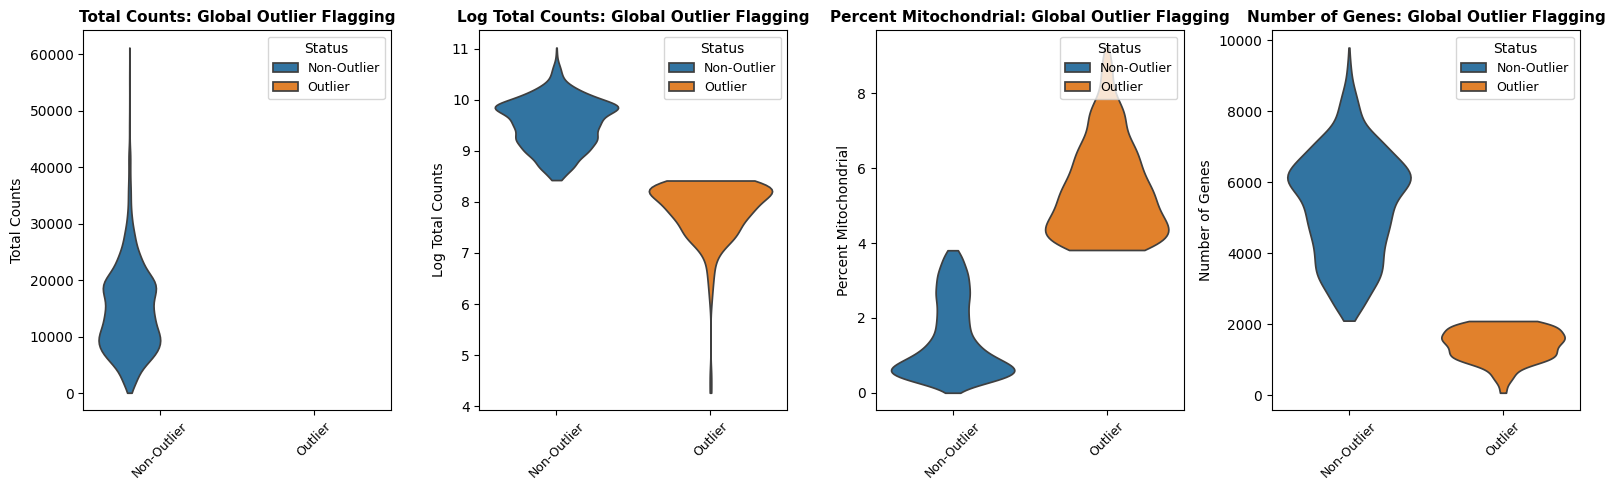

In [16]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

adata.var_names_make_unique()
for col in ['low_counts_outlier', 'low_log_counts_outlier', 'high_mt_outlier', 'low_genes_outlier']:
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=[False, True])

# metric, flag, readable title, y-axis label
pairs = [
    ('total_counts', 'low_counts_outlier', 'Total Counts: Global Outlier Flagging', 'Total Counts'),
    ('log_total_counts', 'low_log_counts_outlier', 'Log Total Counts: Global Outlier Flagging', 'Log Total Counts'),
    ('pct_counts_mt', 'high_mt_outlier', 'Percent Mitochondrial: Global Outlier Flagging', 'Percent Mitochondrial'),
    ('n_genes_by_counts', 'low_genes_outlier', 'Number of Genes: Global Outlier Flagging', 'Number of Genes')
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title, ylabel) in zip(axes, pairs):
    sc.pl.violin(
        adata,
        keys=metric,
        groupby=flag,
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)

    # Replace generic x-axis tick labels (True/False -> Outlier/Non-Outlier)
    ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, ['Non-Outlier', 'Outlier'], title="Status", loc='upper right', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()


**Total Counts**

Spotplot:

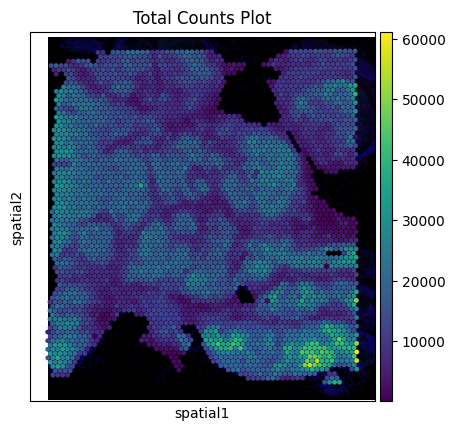

In [23]:
sc.pl.spatial(
    adata,
    color="total_counts",  
    cmap="viridis",
    size=1.4,
    title="Total Counts Plot",
)

Global QC Plot:

Colored = 0 / 4,169 (0.00%)


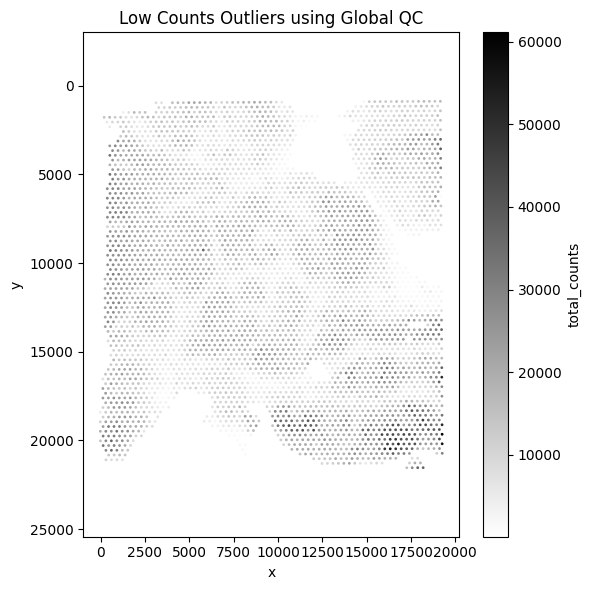

In [41]:
from typing import Optional, Sequence

def plot_qc_metric_with_outliers(
    adata,
    sample_id: str = "region",
    sample: Optional[str] = None,
    metric: str = "total_counts",
    outliers: str = "qc_outlier",
    point_size: float = 2,
    colors: Sequence[str] = ("white", "black"),
    stroke: float = 1.0,
    coord_key: str = "spatial",
    title_prefix: str = "QC Metric",
    title: Optional[str] = None,  # customizable title
):
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from matplotlib.colors import LinearSegmentedColormap

    # Select sample
    if sample_id is None or sample_id not in adata.obs.columns:
        adata_sub = adata.copy()  # use all spots (single sample)
    else:
        if sample is None:
            sample = adata.obs[sample_id].unique()[0]
        mask = np.array(adata.obs[sample_id] == sample)
        adata_sub = adata[mask].copy()

    # Build dataframe
    coords = np.array(adata_sub.obsm[coord_key])
    df = pd.DataFrame(coords, columns=["x", "y"], index=adata_sub.obs_names)
    df[metric] = adata_sub.obs[metric].astype(float)
    df["outlier"] = adata_sub.obs[outliers].astype(bool)
    
    # Condition: nonzero counts & outliers
    df["color_condition"] = (df[metric] > 0) & (df["outlier"])

    # Color scale
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    # Base plot
    plt.figure(figsize=(6, 6))
    base = plt.scatter(
        df["x"], df["y"],
        c=df[metric], cmap=cmap, s=point_size**2,
        linewidths=0, rasterized=True
    )

    # Highlighted overlay
    highlighted = df[df["color_condition"]]
    print(f"Colored = {len(highlighted):,} / {len(df):,} "
          f"({len(highlighted)/len(df)*100:.2f}%)")

    plt.scatter(
        highlighted["x"], highlighted["y"],
        facecolors="none",
        edgecolors="red",
        linewidths=stroke * 1.5,
        alpha=0.8,
        s=(point_size * 1.4) ** 2,
    )

    # Axes and labels
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.colorbar(base, label=metric)

    # Title: use custom if provided
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Global {title_prefix}: {metric} ({sample})")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    return plt


plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="total_counts",
    outliers="low_counts_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Low Counts Outliers using Global QC"
)
plt.show()

Note no outliers flagged!

Then, we apply SpotSweeper on the data, with respect to the total counts metric. In the figure, the red spots are spots that are flagged as low outliers with respect to the total counts metric.  
Runtime on a compute node: 1.2 seconds.

total_counts_outliers
False    4128
True       41
Name: count, dtype: int64

Flagged: 41/4169 spots (0.98%)


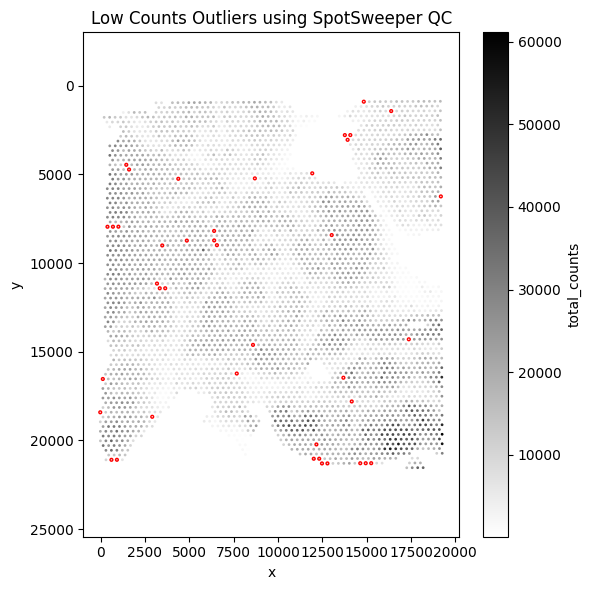

In [30]:
import spotsweeper.local_outliers as lo
import spotsweeper.plot_QC as plot_QC

adata.obs["region"] = "CytAssist_FFPE_Protein_Expression_Human_Breast_Cancer" # define a region column for the data

lo.local_outliers(adata, metric = "total_counts", sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "total_counts", outliers="total_counts_outliers", title="Low Counts Outliers using SpotSweeper QC") # plot outliers

# print summary of outliers detected
col = "total_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

We then repeat for log total counts, number of genes by counts, and % mitochondrial counts metrics.

**Log Total Counts:**

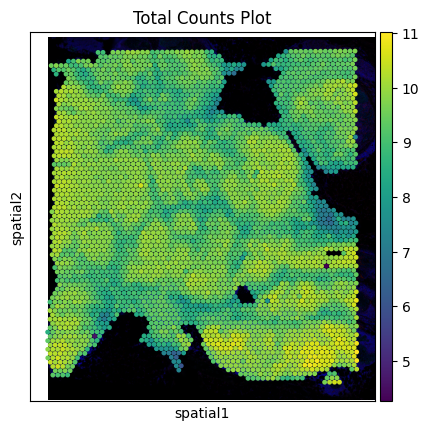

Colored = 229 / 4,169 (5.49%)


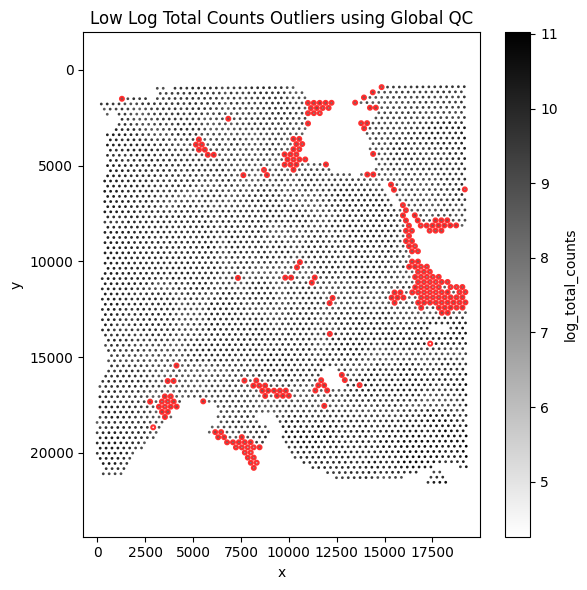

log_total_counts_outliers
False    4122
True       47
Name: count, dtype: int64

Flagged: 47/4169 spots (1.13%)


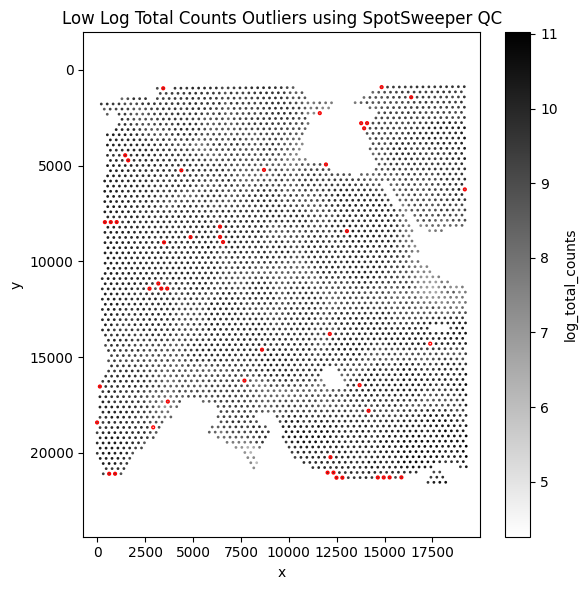

In [40]:
sc.pl.spatial(
    adata,
    color="log_total_counts",  
    cmap="viridis",
    size=1.4,
    title="Total Counts Plot",
)

plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="log_total_counts",
    outliers="low_log_counts_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Low Log Total Counts Outliers using Global QC"
)
plt.show()

lo.local_outliers(adata, metric = "log_total_counts", sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="Low Log Total Counts Outliers using SpotSweeper QC") # plot outliers
# print summary of outliers detected
col = "log_total_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

**Number of genes by counts**

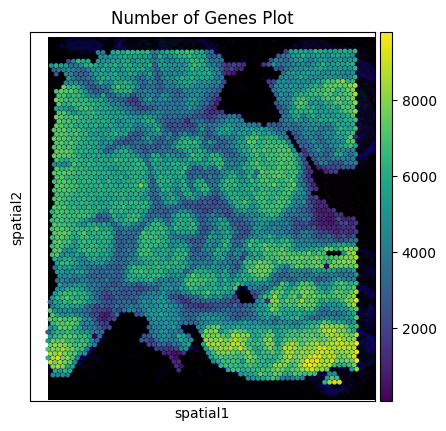

Colored = 150 / 4,169 (3.60%)


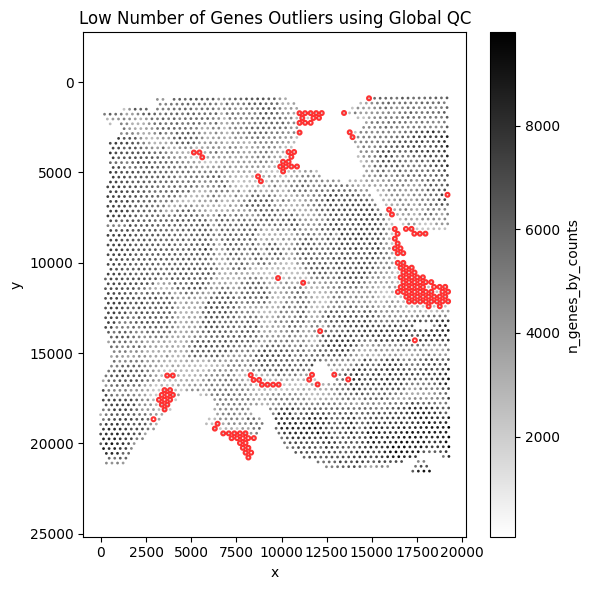

log_total_counts_outliers
False    4122
True       47
Name: count, dtype: int64

Flagged: 47/4169 spots (1.13%)


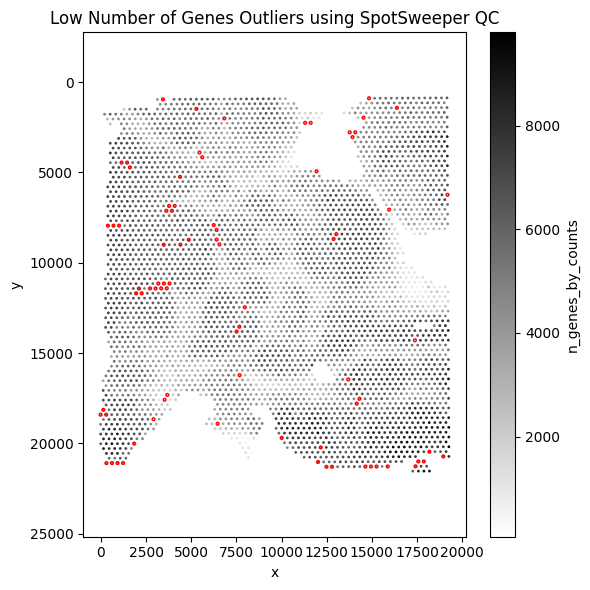

In [43]:
sc.pl.spatial(
    adata,
    color="n_genes_by_counts",  
    cmap="viridis",
    size=1.4,
    title="Number of Genes Plot",
)

plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="n_genes_by_counts",
    outliers="low_genes_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Low Number of Genes Outliers using Global QC"
)
plt.show()

lo.local_outliers(adata, metric = "n_genes_by_counts", sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "n_genes_by_counts", outliers="n_genes_by_counts_outliers", title="Low Number of Genes Outliers using SpotSweeper QC") # plot outliers
# print summary of outliers detected
col = "log_total_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

**% mitochondrial counts:**

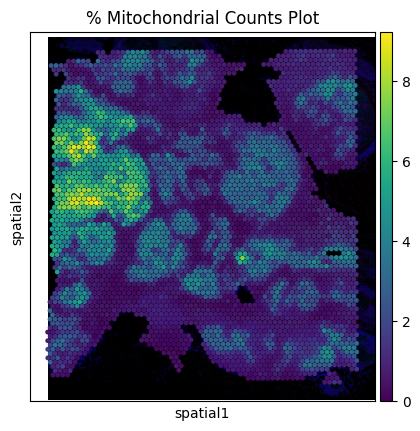

Colored = 608 / 4,169 (14.58%)


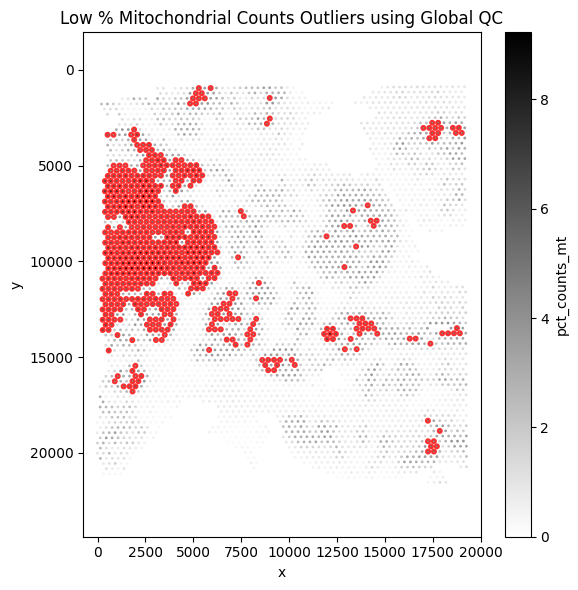

log_total_counts_outliers
False    4122
True       47
Name: count, dtype: int64

Flagged: 47/4169 spots (1.13%)


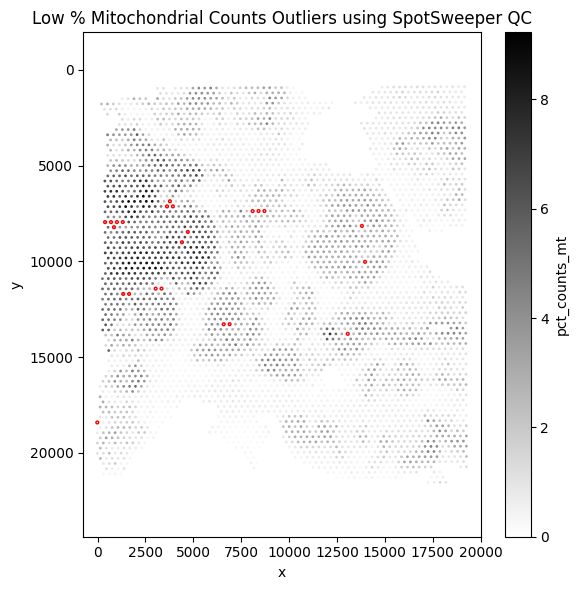

In [42]:
sc.pl.spatial(
    adata,
    color="pct_counts_mt",  
    cmap="viridis",
    size=1.4,
    title="% Mitochondrial Counts Plot",
)

plot_qc_metric_with_outliers(
    adata=adata,
    sample_id=None,
    metric="pct_counts_mt",
    outliers="high_mt_outlier",       # boolean column
    point_size=2,
    colors=("white", "black"),  # background color gradient
    stroke=1,
    title="Low % Mitochondrial Counts Outliers using Global QC"
)
plt.show()

lo.local_outliers(adata, metric = "pct_counts_mt", sample_key = "region")
plot_QC.plot_qc_metrics(adata,"region", metric = "pct_counts_mt", outliers="pct_counts_mt_outliers", title="Low % Mitochondrial Counts Outliers using SpotSweeper QC") # plot outliers
# print summary of outliers detected
col = "log_total_counts_outliers"
counts = adata.obs[col].value_counts()
total = counts.sum()
flagged = counts.get(True, 0)  # safely handle if no True values

print(counts)
print(f"\nFlagged: {flagged}/{total} spots ({flagged/total*100:.2f}%)")

Local Outlier Violin Plots:

/tmp/ipykernel_3472503/3178247165.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/3178247165.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/3178247165.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/3178247165.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)


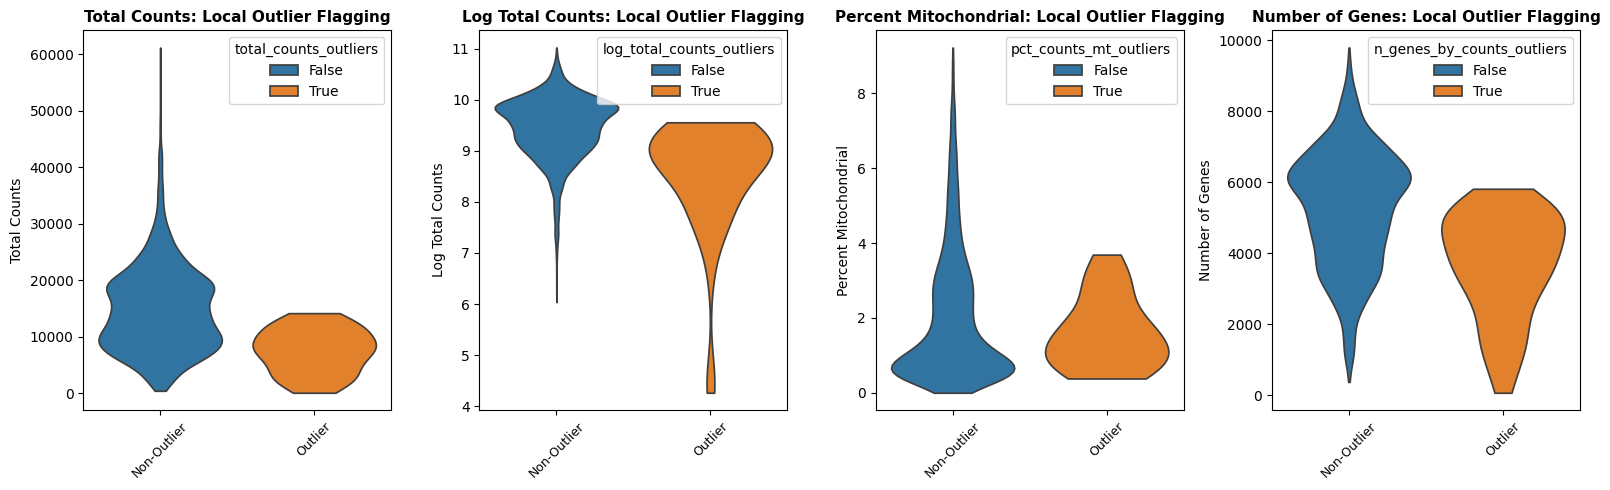

total_counts_outliers
False    4128
True       41
Name: count, dtype: int64
log_total_counts_outliers
False    4122
True       47
Name: count, dtype: int64
pct_counts_mt_outliers
False    4146
True       23
Name: count, dtype: int64
n_genes_by_counts_outliers
False    4089
True       80
Name: count, dtype: int64
all_local_metrics_outliers
False    4071
True       98
Name: count, dtype: int64


/tmp/ipykernel_3472503/3178247165.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_3472503/3178247165.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


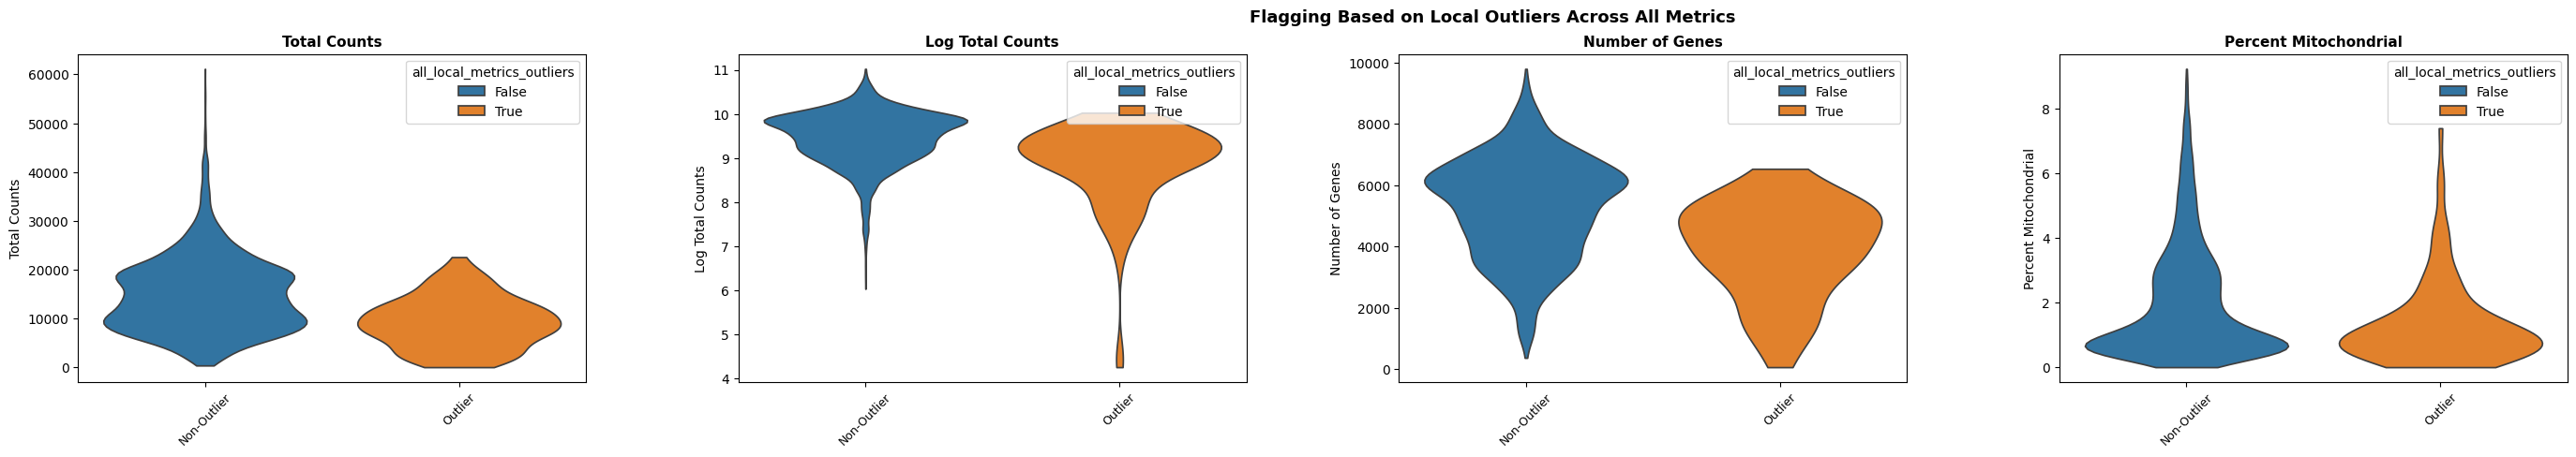

In [44]:
adata.var_names_make_unique()
for col in ['total_counts_outliers', 'log_total_counts_outliers', 'n_genes_by_counts_outliers', 'pct_counts_mt_outliers']:
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=[False, True])

# Define metric–flag mapping
pairs = [
    ('total_counts', 'total_counts_outliers', 'Total Counts'),
    ('log_total_counts', 'log_total_counts_outliers', 'Log Total Counts'),
    ('pct_counts_mt', 'pct_counts_mt_outliers', 'Percent Mitochondrial'),
    ('n_genes_by_counts', 'n_genes_by_counts_outliers', 'Number of Genes')
]

# Create 4-panel figure
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, label) in zip(axes, pairs):
    sc.pl.violin(
        adata,
        keys=metric,
        groupby=flag,
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(f"{label}: Local Outlier Flagging", fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)

plt.tight_layout()
plt.show()

# combine into one global flag
adata.obs['all_local_metrics_outliers'] = (
    adata.obs['total_counts_outliers'].astype(bool)
    | adata.obs['log_total_counts_outliers'].astype(bool)
    | adata.obs['pct_counts_mt_outliers'].astype(bool)
    | adata.obs['n_genes_by_counts_outliers'].astype(bool)
)

print(adata.obs['total_counts_outliers'].value_counts())
print(adata.obs['log_total_counts_outliers'].value_counts())
print(adata.obs['pct_counts_mt_outliers'].value_counts())
print(adata.obs['n_genes_by_counts_outliers'].value_counts())
print(adata.obs['all_local_metrics_outliers'].value_counts())

adata.obs['all_local_metrics_outliers'] = pd.Categorical(adata.obs['all_local_metrics_outliers'], categories=[False, True])

axes = sc.pl.violin(
    adata,
    keys=['total_counts', 'log_total_counts', 'n_genes_by_counts', 'pct_counts_mt'],
    groupby='all_local_metrics_outliers',  # group by TRUE/FALSE
    jitter=0.4,
    stripplot=False,
    rotation=45,
    multi_panel=True,
    show=False
)

fig = axes[0].figure
fig.suptitle("Flagging Based on Local Outliers Across All Metrics", fontsize=13, fontweight='bold')

for ax, label in zip(axes, ['Total Counts', 'Log Total Counts', 'Number of Genes', 'Percent Mitochondrial']):
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(['Non-Outlier', 'Outlier'], fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()